In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


**Step 2 :Load the data**


In [2]:
df = pd.read_csv("01_Raw\Customer_Churn_Raw.csv",encoding='latin-1')

**Check columns and datatypes**


In [27]:
# STEP 3: First look
print(f'Dataset Shape: {df.shape}')     # Rows, Columns
print(f'Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'Null Vlaues : {df.isnull().sum().sum()}Total')
df.head(5)                              


Dataset Shape: (594194, 35)
Memory Usage: 591.01 MB
Null Vlaues : 0Total


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,InternetService_bin,OnlineSecurity_bin,OnlineBackup_bin,DeviceProtection_bin,TechSupport_bin,StreamingTV_bin,StreamingMovies_bin,Service_Count,Avg_spend_per_service,High_Risk_Flag
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,0,1,0,1,1,0,0,4,15.02,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,0,1,1,0,1,1,0,5,13.90,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,0,0,1,0,0,1,1,5,20.08,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,0,0,0,0,0,0,0,1,69.70,0
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,0,0,0,0,0,0,0,1,70.45,0


**Step3: Check columns and datatypes**

In [4]:
# See all columns and their types
print(df.dtypes)
print('\n--- Column List ---')
print(df.columns.tolist())


id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

--- Column List ---
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


**Step4: Check null and Missing values**

In [5]:
# Count and percentage of nulls per column
null_count = df.isnull().sum()
null_pct   = (df.isnull().sum() / len(df) * 100).round(2)
null_report = pd.DataFrame({
    'Missing Count': null_count,
    'Missing %':     null_pct
}).query('`Missing Count` > 0')  # Show only columns with nulls

print(null_report)
print(null_count)
print(null_pct)


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
id                  0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCh

**Step 5:Duplicates Rows**

In [6]:
# Check for exact duplicate rows
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

# Check for duplicate CustomerIDs (should be unique)
if 'customerID' in df.columns:
    cust_dups = df['customerID'].duplicated().sum()
    print(f'Duplicate CustomerIDs: {cust_dups}')


Duplicate rows: 0


**Step 6:Class Imbalance**

Churn Distribution:
Churn
No     77.48
Yes    22.52
Name: proportion, dtype: float64


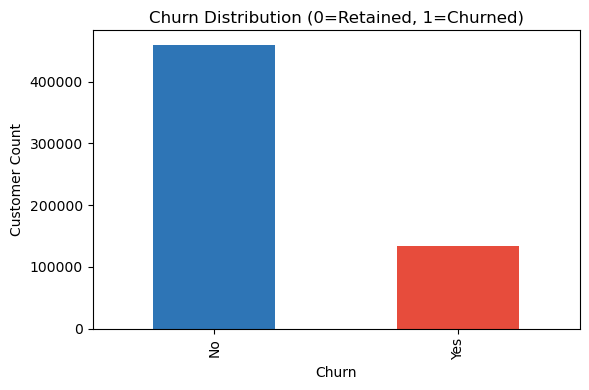

In [7]:
# Check churn distribution
churn_dist = df['Churn'].value_counts(normalize=True) * 100
print('Churn Distribution:')
print(churn_dist.round(2))

# Visualise it
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['#2E75B6', '#E74C3C'])
plt.title('Churn Distribution (0=Retained, 1=Churned)')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()


**Step 7:Descriptive statistics**

In [8]:
# Full statistical summary
df.describe(include='all').T

# Separate numeric and categorical
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')


Numeric columns (5): ['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


**Step 8:Unique value in Categorical column**

In [9]:
# See unique values per categorical column
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()


--- gender ---
gender
Female    298738
Male      295456
Name: count, dtype: int64

--- Partner ---
Partner
Yes    309554
No     284640
Name: count, dtype: int64

--- Dependents ---
Dependents
No     414362
Yes    179832
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    557893
No      36301
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     250083
Yes                    203384
No internet service    140727
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     247377
Yes      

**Step 9:Handle Duplicates**


In [10]:
print(f'Before:{df.shape}')
df = df.drop_duplicates()
print(f'After:{df.shape}')
print(f'Remove:{594194-len(df)}Duplicates Rows')

Before:(594194, 21)
After:(594194, 21)
Remove:0Duplicates Rows


**Step 10:Fix Datatypes**


In [11]:
# TotalCharges is often stored as string — convert it
if df['TotalCharges'].dtype == 'float64':
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print('TotalCharges converted to numeric')
    print(f'New nulls created: {df["TotalCharges"].isnull().sum()}')




TotalCharges converted to numeric
New nulls created: 0


In [12]:
# Convert Churn to integer (0/1) if it's Yes/No
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    print('Churn mapped to 0/1')




Churn mapped to 0/1


**Step11:Handle Missing values**


In [13]:
#Now it's time to handle nulls values
#TotalCharges: new customers (tenure=0) have no total charges -fill with 0
df['TotalCharges'] =df['TotalCharges'].fillna(0)

#For numeric columns:fill with median(robust to outliers)
for col in df.select_dtypes(include='float64').columns:
    if df[col].isnull().sum() >0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'{col}: filled {df[col].isnull().sum()} nulls with median={median_val:.2f}')
        
#Final check -should be zero
print(f'\nRemaining nulls:  {df.isnull().sum().sum()}')



Remaining nulls:  0


**Step 12:Standardise Categorical columns**

In [14]:
replace_map = {'No internet service':'NO'},
{'No Mobile service': 'NO'}
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection','Techsupport','StreamingTV','StreamingMovies'
'MultipleLines']
for col in service_cols:
    if col in df.columns:
        df[col] = df[col].replace(replace_map)
        print(f'{col}:unique values ={df[col].unique()}')




OnlineSecurity:unique values =['Yes' 'No' 'No internet service']
OnlineBackup:unique values =['No' 'Yes' 'No internet service']
DeviceProtection:unique values =['Yes' 'No' 'No internet service']
StreamingTV:unique values =['No' 'Yes' 'No internet service']


**Feature Engineering**

**Feature1: Tenure Bucket**

In [15]:
# Segment customers by how long they've been with us

def tenure_bucket(tenure):
    if tenure <=12:
        return 'New(0-12 mo)'
    elif tenure <=36:
        return 'Growing (13-36 mo)'
    else:
        return'Loyal(36+ mo)'

df['tenure_bucket'] = df['tenure'].apply(tenure_bucket)

#validate
print(df['tenure_bucket'].value_counts())
print(df.groupby('tenure_bucket')['Churn'].mean().round(3) * 100)

tenure_bucket
Loyal(36+ mo)         289349
New(0-12 mo)          152646
Growing (13-36 mo)    152199
Name: count, dtype: int64
tenure_bucket
Growing (13-36 mo)    25.1
Loyal(36+ mo)          7.0
New(0-12 mo)          49.4
Name: Churn, dtype: float64


**FEATURE 2 — Revenue At Risk**


In [16]:
# Annual revenue at risk for each customer
df['Annual_Revenue'] = df['MonthlyCharges'] * 12

# Revenue at risk only for churned customers
total_revenue_at_risk = df[df['Churn'] == 1]['Annual_Revenue'].sum()
print(f'Total Annual Revenue At Risk: ${total_revenue_at_risk:,.0f}')

# Average revenue at risk per churned customer
avg_risk = df[df['Churn'] == 1]['Annual_Revenue'].mean()
print(f'Avg Revenue At Risk per Churned Customer: ${avg_risk:,.0f}')


Total Annual Revenue At Risk: $131,029,632
Avg Revenue At Risk per Churned Customer: $979


**Feature3 : Service Count**

In [17]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
#Map Yes=1, No/else=0 for each service column
for col in service_cols:
    df[col + '_bin'] = (df[col] == 'Yes').astype(int)

bin_cols = [col + '_bin' for col in service_cols]
df['Service_Count'] = df[bin_cols].sum(axis=1)

# Analyse: does more services = less churn?
print(df.groupby('Service_Count')['Churn'].mean().round(3))


Service_Count
0    0.346
1    0.110
2    0.303
3    0.376
4    0.375
5    0.283
6    0.179
7    0.065
8    0.021
Name: Churn, dtype: float64


**Feature 4 :Average spend per service**


In [18]:
df['Avg_spend_per_service'] = np.where(
    df['Service_Count'] > 0,
    df['MonthlyCharges'] / df['Service_Count'],
    0
) 
df['Avg_spend_per_service']= df['Avg_spend_per_service'].round(2)
print(df['Avg_spend_per_service'].describe())




    

count    594194.000000
mean         22.518445
std          12.254475
min           0.000000
25%          15.470000
50%          19.800000
75%          24.020000
max          93.700000
Name: Avg_spend_per_service, dtype: float64



**FEATURE 5 — Churn Risk Flag (Rule-Based)**

In [19]:
# Create a business-rule risk flag BEFORE we build the ML model
# Based on known churn drivers: month-to-month contract + high charges + new customer

df['High_Risk_Flag'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['tenure'] <= 12)
).astype(int)


In [20]:
# Validate — what % of high-risk customers actually churned?
risk_churn = df[df['High_Risk_Flag'] == 1]['Churn'].mean() * 100
normal_churn = df[df['High_Risk_Flag'] == 0]['Churn'].mean() * 100
print(f'High-Risk Flag Churn Rate: {risk_churn:.1f}%')
print(f'Normal Customer Churn Rate: {normal_churn:.1f}%')


High-Risk Flag Churn Rate: 73.7%
Normal Customer Churn Rate: 15.8%


**Export : clean data**

In [21]:
df.to_csv("02_Cleaned\Customer_Churn_cleaned.csv",index = False)

In [23]:
print(f'Cleaned dataset saved to: {df.to_csv("02_Cleaned\Customer_Churn_cleaned.csv",index = False)}')
print(f'File size: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns : {df.columns.tolist()}')

Cleaned dataset saved to: None
File size: 594,194 rows x 35 columns
Columns : ['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_bucket', 'Annual_Revenue', 'PhoneService_bin', 'MultipleLines_bin', 'InternetService_bin', 'OnlineSecurity_bin', 'OnlineBackup_bin', 'DeviceProtection_bin', 'TechSupport_bin', 'StreamingTV_bin', 'StreamingMovies_bin', 'Service_Count', 'Avg_spend_per_service', 'High_Risk_Flag']


In [24]:
print(f'Cleaned dataset saved to: {df.to_csv("02_Cleaned\Customer_Churn_cleaned.csv",index = False)}')
print(f'File size: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns : {df.columns.tolist()}')

Cleaned dataset saved to: None
File size: 594,194 rows x 35 columns
Columns : ['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_bucket', 'Annual_Revenue', 'PhoneService_bin', 'MultipleLines_bin', 'InternetService_bin', 'OnlineSecurity_bin', 'OnlineBackup_bin', 'DeviceProtection_bin', 'TechSupport_bin', 'StreamingTV_bin', 'StreamingMovies_bin', 'Service_Count', 'Avg_spend_per_service', 'High_Risk_Flag']


In [26]:

verify = pd.read_csv("02_Cleaned\Customer_Churn_cleaned.csv", encoding='latin-1')
print(f'\n✅ Verification: {verify.shape} — file is readable')



✅ Verification: (594194, 35) — file is readable


**END -- FILE CLEANING**